# CMI with $S$: full plaquette-stabilizer toric-code ring

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce


We now use the full square plaquette stabilizers for a $1\times 4$ plaquette ring.

There are $4$ plaquettes and $12$ physical edge qubits. I use the following qubit labeling:

\[
\begin{aligned}
&0,1,2,3 &&\text{top edges } t_0,t_1,t_2,t_3,\\
&4,5,6,7 &&\text{bottom edges } b_0,b_1,b_2,b_3,\\
&8,9,10,11 &&\text{vertical shared edges } v_0,v_1,v_2,v_3.
\end{aligned}
\]

Plaquette $p_i$ has boundary edges

\[
\partial p_i = \{t_i,b_i,v_i,v_{i+1}\},
\]

with periodic indexing $v_4 \equiv v_0$. Therefore the full plaquette stabilizer is

\[
B_i = Z_{t_i}Z_{b_i}Z_{v_i}Z_{v_{i+1}},
\qquad i=0,1,2,3.
\]

The plaquette-only ground-state density matrix is the normalized stabilizer projector

\[
\rho_{\rm gs}
= \frac{P_{\rm gs}}{{\rm Tr}(P_{\rm gs})},
\qquad
P_{\rm gs}=\prod_{i=0}^{3}\frac{I+B_i}{2}.
\]


In [2]:
# Defining rho_gs for a 1 x 4 full-plaquette ring with 12 edge qubits

# -------------------------
# Parameters and qubit labeling
# -------------------------
num_plaquettes = 4
N = 12  # total physical edge qubits

# Qubit labels:
# top edges:      0, 1, 2, 3
# bottom edges:   4, 5, 6, 7
# vertical edges: 8, 9, 10, 11
# Plaquette p_i uses [top_i, bottom_i, vertical_i, vertical_{i+1 mod 4}]
plaquette_edges = []
for i in range(num_plaquettes):
    top_i = i
    bottom_i = num_plaquettes + i
    vertical_left_i = 2 * num_plaquettes + i
    vertical_right_i = 2 * num_plaquettes + ((i + 1) % num_plaquettes)
    plaquette_edges.append([top_i, bottom_i, vertical_left_i, vertical_right_i])

shared_edge_qubits = list(range(2 * num_plaquettes, 3 * num_plaquettes))

print("Plaquette boundary qubits:")
for i, edges in enumerate(plaquette_edges):
    print(f"  p_{i}: {edges}")
print("Shared vertical edge qubits where bit-flip noise acts:", shared_edge_qubits)

# -------------------------
# Pauli matrices and helpers
# -------------------------
Pauli_X = np.array([[0, 1], [1, 0]], dtype=complex)
Pauli_Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

def bit_at(index, qubit, N):
    """Return the computational-basis bit at qubit, where qubit 0 is leftmost/MSB."""
    return (index >> (N - 1 - qubit)) & 1

def plaquette_eigenvalue(index, edges, N):
    """
    Eigenvalue of B_p = product Z_e on a computational-basis state.
    It is +1 for even parity on the plaquette boundary and -1 for odd parity.
    """
    parity = sum(bit_at(index, q, N) for q in edges) % 2
    return 1 if parity == 0 else -1

# -------------------------
# Build the normalized full plaquette ground-state projector
# -------------------------
# Since all B_p are products of Z operators, the ground-state projector is diagonal
# in the computational basis. A basis state survives iff every plaquette has +1 parity.

dim = 2 ** N
allowed_basis_indices = []

for basis_index in range(dim):
    if all(plaquette_eigenvalue(basis_index, edges, N) == 1 for edges in plaquette_edges):
        allowed_basis_indices.append(basis_index)

rank_gs = len(allowed_basis_indices)
rho_gs = np.zeros(dim, dtype=float)
rho_gs[allowed_basis_indices] = 1 / rank_gs

print("\nGround-state density matrix shape: (", dim, ",", dim, ")", sep="")
print("Trace:", np.sum(rho_gs))
print("Ground-space dimension = rank(P_gs):", rank_gs)
print("Each nonzero diagonal entry of rho_gs:", 1 / rank_gs)

# -------------------------
# Print the full-system ground-state density matrix
# -------------------------
# A 12-qubit density matrix is 4096 x 4096, so printing every entry is extremely long.
# The compact print below gives all nonzero entries of the full-system density matrix.
print("\nNonzero entries of the full-system rho_gs, as (row, col, value):")
for idx in allowed_basis_indices:
    print((idx, idx, rho_gs[idx]))

# If you really want NumPy to print the dense 4096 x 4096 matrix, set this to True.
PRINT_FULL_DENSE_RHO = False
if PRINT_FULL_DENSE_RHO:
    np.set_printoptions(threshold=np.inf, linewidth=200)
    print(np.diag(rho_gs))


# All density matrices in this notebook are stored by their diagonal probability vector.
# This is exactly equivalent to storing the full diagonal density matrix, but much faster.
DIAGONAL_VECTOR_REPRESENTATION = True


Plaquette boundary qubits:
  p_0: [0, 4, 8, 9]
  p_1: [1, 5, 9, 10]
  p_2: [2, 6, 10, 11]
  p_3: [3, 7, 11, 8]
Shared vertical edge qubits where bit-flip noise acts: [8, 9, 10, 11]

Ground-state density matrix shape: (4096,4096)
Trace: 1.0
Ground-space dimension = rank(P_gs): 256
Each nonzero diagonal entry of rho_gs: 0.00390625

Nonzero entries of the full-system rho_gs, as (row, col, value):
(0, 0, np.float64(0.00390625))
(15, 15, np.float64(0.00390625))
(49, 49, np.float64(0.00390625))
(62, 62, np.float64(0.00390625))
(83, 83, np.float64(0.00390625))
(92, 92, np.float64(0.00390625))
(98, 98, np.float64(0.00390625))
(109, 109, np.float64(0.00390625))
(151, 151, np.float64(0.00390625))
(152, 152, np.float64(0.00390625))
(166, 166, np.float64(0.00390625))
(169, 169, np.float64(0.00390625))
(196, 196, np.float64(0.00390625))
(203, 203, np.float64(0.00390625))
(245, 245, np.float64(0.00390625))
(250, 250, np.float64(0.00390625))
(272, 272, np.float64(0.00390625))
(287, 287, np.float64(0.

Next, define the bit-flip noise channel on the vertical shared edges between neighboring plaquettes:

\[
\mathcal{E}^{i}_p(\rho)=(1-p)\rho+pX_i\rho X_i.
\]

For the $1\times 4$ ring, the noisy qubits are

\[
 i\in\{8,9,10,11\},
\]

corresponding to $v_0,v_1,v_2,v_3$. The full channel acts independently on those shared edges only:

\[
\mathcal{E}_p(\rho)=\prod_{i\in\{8,9,10,11\}}\mathcal{E}^{i}_p(\rho).
\]

A bit flip on $v_i$ anticommutes with the two neighboring plaquette stabilizers that contain that edge.

In [3]:
# Defining the bit-flip noise channel on shared vertical edges

# Pauli_X and I2 were already defined above.

def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in an N-qubit system.
    This is useful for small checks.
    """
    ops = [I2] * N
    ops[i] = op
    return reduce(np.kron, ops)


def bit_flip_indices(i, N):
    """
    Return the computational-basis permutation corresponding to X_i.

    The convention here matches the tensor-product ordering used by np.kron:
    qubit 0 is the leftmost / most significant qubit.
    """
    dim = 2 ** N
    mask = 1 << (N - 1 - i)
    return np.arange(dim) ^ mask


def conjugate_by_X_i(rho, i, N):
    """
    Compute X_i rho X_i.

    Here rho is stored as the diagonal probability vector of the full density
    matrix, so conjugation by X_i just permutes that vector.
    """
    perm = bit_flip_indices(i, N)
    return rho[perm]


def bit_flip_channel(rho, p, i, N):
    """
    Apply a bit-flip channel to qubit i.
    """
    return (1 - p) * rho + p * conjugate_by_X_i(rho, i, N)


In [4]:
# Test: apply channel on one shared vertical edge
p_test = 0.1
rho_out = bit_flip_channel(rho_gs, p_test, i=shared_edge_qubits[0], N=N)

print("Trace after one local channel:", np.sum(rho_out))
print("Minimum probability:", np.min(rho_out))


Trace after one local channel: 1.0
Minimum probability: 0.0


In [5]:
# Repeated application of bit-flip channel on every shared vertical edge

def noise_channel(rho_0, p, N, noisy_qubits=shared_edge_qubits):
    """
    Apply independent bit-flip noise to the shared vertical edges of the plaquette ring.
    """
    rho = rho_0.copy()
    for i in noisy_qubits:
        rho = bit_flip_channel(rho, p, i, N)
    return rho


In [6]:
# Test: apply full channel to rho_gs
rho_out_2 = noise_channel(rho_gs, p_test, N=N)

print("Trace after full channel:", np.sum(rho_out_2))
print("Minimum probability:", np.min(rho_out_2))


Trace after full channel: 1.0
Minimum probability: 0.0


In [ ]:
#np.savetxt('rho_out_2 .txt', rho_out_2 , fmt='%f', delimiter='\t')


Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 


In [ ]:
#Possible fix: calculating log2 straingth away?


In [7]:
# Calculating von Neumann entropy
def von_neumann_entropy(rho, base=2):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho).

    In this notebook rho is represented by the diagonal probability vector of a
    diagonal density matrix. For a diagonal density matrix, the von Neumann
    entropy is the Shannon entropy of the diagonal probabilities.
    """
    eigvals = np.real(rho)
    eigvals = eigvals[eigvals > 1e-12]

    if base == 2:
        logs = np.log2(eigvals)
    else:
        logs = np.log(eigvals) / np.log(base)

    return -np.sum(eigvals * logs)


In [8]:
#Test

S = von_neumann_entropy(rho_out)
print("Von Neumann entropy:", S)


Von Neumann entropy: 8.46899559358928


In [9]:
def partial_trace(rho, keep, N):
    """
    Partial trace over all qubits not listed in keep.

    Since rho is stored as the diagonal probability vector, the reduced state is
    obtained by marginalizing the probability vector over the qubits that are
    traced out. The returned reduced rho is also a diagonal probability vector.
    """
    keep = sorted(keep)
    dim_keep = 2 ** len(keep)
    reduced_probs = np.zeros(dim_keep, dtype=float)

    for full_index, prob in enumerate(rho):
        if abs(prob) < 1e-15:
            continue
        reduced_index = 0
        for q in keep:
            reduced_index = (reduced_index << 1) | bit_at(full_index, q, N)
        reduced_probs[reduced_index] += prob

    return reduced_probs


In [10]:
#Function to compute reduced density matrix

def partial_trace0(rho, keep, N):
    """
    Partial trace over all subsystems NOT in 'keep'.

    Parameters:
    - rho: full density matrix (2^N x 2^N)
    - keep: list of subsystem indices to keep (e.g. [0,2])
    - N: number of qubits

    Returns:
    - reduced density matrix
    """

    dims = [2] * N

    rho_t = rho.reshape(dims + dims)

    keep = sorted(keep)

    # indices for full system
    all_idx = list(range(N))

    trace_idx = [i for i in all_idx if i not in keep]

    # build einsum string dynamically
    import string

    letters = string.ascii_lowercase + string.ascii_uppercase

    # assign indices for bra and ket spaces
    inds = letters[:N] + letters[N:2*N]

    # build contraction
    keep_bra = [inds[i] for i in keep]
    keep_ket = [inds[i + N] for i in keep]

    einsum_str = ''.join(inds) + '->' + ''.join(keep_bra + keep_ket)

    return np.einsum(einsum_str, rho_t)


Partition into subregions $A$, $B$, and $C$ by plaquettes.

For the $1\times 4$ ring, choose

\[
A=p_0,\qquad B=p_1\cup p_3,\qquad C=p_2.
\]

Because neighboring plaquettes share vertical edge qubits, the plaquette supports overlap. A density-matrix partial trace requires a disjoint partition of physical qubits. In the code below I assign shared boundary qubits by priority

\[
A \rightarrow B \rightarrow C.
\]

So $A$ gets all four edges of $p_0$, $B$ gets the remaining edges belonging to the two neighboring plaquettes, and $C$ gets the remaining edges belonging to $p_2$. This gives a true qubit partition of all 12 physical qubits.

In [11]:
# Plaquette-based partition for the 1 x 4 ring.
# We choose A = plaquette p_0, B = neighboring plaquettes p_1 and p_3, C = last plaquette p_2.
# Since plaquettes share vertical edge qubits, overlapping supports must be converted
# into disjoint qubit regions before taking partial traces.

A_plaquettes = [0]
B_plaquettes = [1, 3]
C_plaquettes = [2]


def qubits_of_plaquettes(plaquette_ids):
    """Return the sorted union of all edge qubits belonging to the given plaquettes."""
    qubits = set()
    for pid in plaquette_ids:
        qubits.update(plaquette_edges[pid])
    return sorted(qubits)

# Raw plaquette supports; these overlap on shared vertical edges.
A_support = qubits_of_plaquettes(A_plaquettes)
B_support = qubits_of_plaquettes(B_plaquettes)
C_support = qubits_of_plaquettes(C_plaquettes)

# Convert overlapping plaquette supports into a disjoint physical-qubit partition.
# Priority convention: A first, then B, then C.
A = A_support
B = sorted(q for q in B_support if q not in A)
C = sorted(q for q in C_support if q not in A and q not in B)

# Sanity checks for a valid partial-trace partition.
assert set(A).isdisjoint(B)
assert set(A).isdisjoint(C)
assert set(B).isdisjoint(C)
assert sorted(A + B + C) == list(range(N)), "A, B, C should cover all 12 qubits exactly once."

print("Plaquette supports before resolving shared-edge overlaps:")
print("  support(A = p0)      =", A_support)
print("  support(B = p1 ∪ p3) =", B_support)
print("  support(C = p2)      =", C_support)

print("\nDisjoint qubit regions used for partial traces:")
print("  A = p0                      ->", A)
print("  B = neighbors p1 and p3, new ->", B)
print("  C = last plaquette p2, new   ->", C)
print("\nRegion sizes:", "|A| =", len(A), "|B| =", len(B), "|C| =", len(C))


Plaquette supports before resolving shared-edge overlaps:
  support(A = p0)      = [0, 4, 8, 9]
  support(B = p1 ∪ p3) = [1, 3, 5, 7, 8, 9, 10, 11]
  support(C = p2)      = [2, 6, 10, 11]

Disjoint qubit regions used for partial traces:
  A = p0                      -> [0, 4, 8, 9]
  B = neighbors p1 and p3, new -> [1, 3, 5, 7, 10, 11]
  C = last plaquette p2, new   -> [2, 6]

Region sizes: |A| = 4 |B| = 6 |C| = 2


In [12]:
def CMI(p, rho_0, A, B, C, N):
    """
    Compute S(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC)
    after applying shared-edge bit-flip noise with probability p.
    """

    rho = noise_channel(rho_0, p, N)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC



In [13]:
def CMI0(p, rho_0, A, B, C, N):

    rho = noise_channel(rho_0, p, N)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N), base=2)
    print(f'S_AB={S_AB}')
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N), base=2)
    print(f'S_BC={S_BC}')
    S_B  = von_neumann_entropy(partial_trace(rho, B, N), base=2)
    print(f'S_B={S_B}')
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N), base=2)
    print(f'S_ABC={S_ABC}')

    print(f'CMI={S_AB + S_BC - S_B - S_ABC}')

    return S_AB + S_BC - S_B - S_ABC


In [14]:
print("A plaquettes =", A_plaquettes)
print("B plaquettes =", B_plaquettes)
print("C plaquettes =", C_plaquettes)
print("\nQubit regions used in CMI:")
print("A =", A)
print("B =", B)
print("C =", C)
print("rho_gs diagonal-vector shape:", rho_gs.shape)
print("Equivalent full density matrix shape:", (2**N, 2**N))
print("N =", N)


A plaquettes = [0]
B plaquettes = [1, 3]
C plaquettes = [2]

Qubit regions used in CMI:
A = [0, 4, 8, 9]
B = [1, 3, 5, 7, 10, 11]
C = [2, 6]
rho_gs diagonal-vector shape: (4096,)
Equivalent full density matrix shape: (4096, 4096)
N = 12


In [15]:
#test

cmi_test = CMI(p_test,rho_gs,A=A,B=B,C=C,N=N)

print(cmi_test)


0.6800770457282859


In [16]:
cmi_test2 = CMI(0.5,rho_gs,A=A,B=B,C=C,N=N)

print(cmi_test2)


1.0


In [17]:
#Array of different noise rates

p_array = np.linspace(0.001,0.999,20)
cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_gs,A=A,B=B,C=C,N=N)


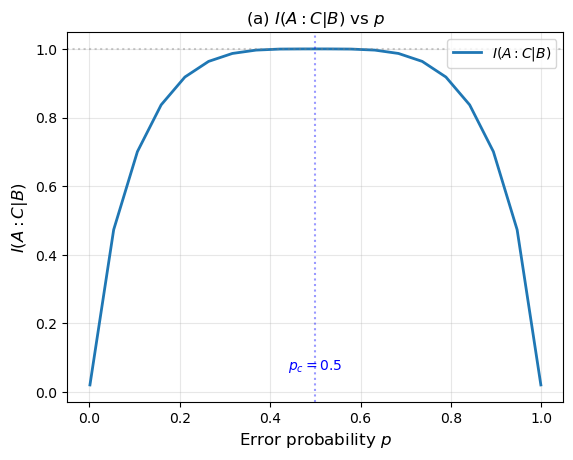

In [18]:
fig, ax = plt.subplots()

ax.plot(p_array, cmi_array,lw=2, label=r'$I(A{:}C|B)$')
#ax.plot(p_values, mi_AC_values, 'r--', lw=1.5, alpha=0.7, label=r'$I(A{:}C)$')
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axvline(0.5, color='blue', ls=':', alpha=0.4)
ax.set_xlabel(r'Error probability $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C|B)$ ', fontsize=12)
ax.set_title(r'(a) $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(r'$p_c = 0.5$', xy=(0.5, 0.05), fontsize=10, color='blue',
            ha='center', va='bottom')

plt.show()


Comment: why CMI values might be a bit inflated, especially compared to the earloer results, calculated with H.


In [19]:
# Check noisy density matrix
rho_test = noise_channel(rho_gs, p_test, N)

print("Trace:", np.sum(rho_test))
print("Minimum probability:", np.min(rho_test))


Trace: 1.0
Minimum probability: 0.0


In [ ]:
# Check ground-state density matrix
print("Trace:", np.sum(rho_gs))
print("Minimum probability:", np.min(rho_gs))
print("Number of nonzero diagonal entries:", np.sum(np.abs(rho_gs) > 1e-12))


In [ ]:
#Array of different noise rates

p_array = np.linspace(0.001,0.999,40)
cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_gs,A=A,B=B,C=C,N=N)
